In [1]:
import geopandas as gpd
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the shapefile containing the coastal profiles
profiles = gpd.read_file(os.path.join("data", "profiles",  "perfiles_playas_limpiosCuadrantes94a120.shp"))
# Create a new column for the profile ID
profiles["profile_id"] = profiles["ID_Perfil"].astype(int)

# Load the shorelines
shorelines = gpd.read_file(os.path.join("data", "shorelines",  "LineasCosta.gpkg"),
                           layer="LineasCostaPlayas")
# Keep only the relevant columns
columns_to_keep = ["ID_LineaCosta", "Mision", "Municipio", "Playa", "Fecha", "Hora", "Cuadrante", "NivelTotal"]
shorelines = shorelines[columns_to_keep + ["geometry"]]
# Filter the shorelines to keep only those where "Cuadrante" is between 94 and 120
shorelines = shorelines[(shorelines["Cuadrante"] >= 94) & (shorelines["Cuadrante"] <= 120)]

# Ensure both GeoDataFrames use the same coordinate reference system (CRS)
profiles = profiles.to_crs(shorelines.crs)
print(f"Profiles CRS: {profiles.crs}")

Profiles CRS: EPSG:25830


In [3]:
# Intersect profiles and shorelines, retaining only point intersections.
profiles_shoreline_intersections = gpd.overlay(
    profiles[["profile_id", "geometry"]],
    shorelines,
    how="intersection",
    keep_geom_type=False,
).explode(index_parts=False, ignore_index=True)
profiles_shoreline_intersections = profiles_shoreline_intersections[
    profiles_shoreline_intersections.geometry.geom_type == "Point"
].copy()

# Shapely's project() returns the along-profile distance in the CRS units (meters here).
profile_geometries = profiles.set_index("profile_id").geometry
profiles_shoreline_intersections["shoreline_position_m"] = (
    profiles_shoreline_intersections.apply(
        lambda row: profile_geometries.loc[row["profile_id"]].project(row.geometry),
        axis=1,
    )
)

# Remove multiple intersections for the same profile and shoreline.
# The shoreline identifier in this dataset is ID_LineaCosta.
profiles_shoreline_intersections = (
    profiles_shoreline_intersections
    .sort_values("shoreline_position_m")
    .drop_duplicates(
        subset=["profile_id", "ID_LineaCosta"],
        keep="first",
    )
)

profiles_shoreline_intersections = gpd.GeoDataFrame(
    profiles_shoreline_intersections[
        ["profile_id"] + columns_to_keep + ["shoreline_position_m", "geometry"]
    ],
    geometry="geometry",
    crs=profiles.crs,
)

# Create a single column for the date and time of the shoreline measurement
profiles_shoreline_intersections["datetime"] = pd.to_datetime(
    profiles_shoreline_intersections["Fecha"].astype(str)
    + " "
    + profiles_shoreline_intersections["Hora"].astype(str),
    #format="%Y%m%d %H%M",
    errors="coerce",
)
# Add the same column to the shorelines GeoDataFrame
shorelines["datetime"] = pd.to_datetime(
    shorelines["Fecha"].astype(str) + " " + shorelines["Hora"].astype(str),
    #format="%Y%m%d %H%M",
    errors="coerce",
)

In [4]:
from shoreline_evolution_viz import create_shoreline_dashboard

dashboard = create_shoreline_dashboard(
    profiles,
    shorelines,
    profiles_shoreline_intersections,
    display_widget=True,
)

In [5]:
from utils import SmartTidalFilter

# Initialize the filter with all available parameters explicitly defined
tidal_filter = SmartTidalFilter(
    min_years_span=5.0,                # Minimum temporal span required for a tidal window (in years)
    max_gap_years=5.0,                 # Maximum continuous gap allowed between consecutive data points (in years)
    lambda_1=2.0,                      # Penalty weight for the amplitude of the tidal window (reduces topographic noise)
    lambda_2=1.5,                      # Penalty weight for losing recent data (penalizes windows that drop present years)
    window_sizes=[0.2, 0.4, 0.6, 0.8, 1.0], # List of tidal window widths to test during the optimization search (in meters)
    step_size=0.1,                     # Step size to slide the tidal window across the beach's tidal range (in meters)
    beach_col="Playa",                 # DataFrame column name containing the beach or spatial unit identifier
    tide_col="NivelTotal",             # DataFrame column name containing the sea level/tidal height values
    date_col="datetime"                # DataFrame column name containing the pre-processed datetime objects
)

# Apply the filter to the geospatial dataset
filtered_data = tidal_filter.fit_transform(profiles_shoreline_intersections)

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

def visualizar_resultado_filtro(df_original, df_filtrado, profile_id, filtro_instancia, date_col="datetime"):
    """
    Compara los datos originales y filtrados, incluyendo la distribución
    de los valores de NivelTotal.
    """
    df_orig_perfil = df_original[
        df_original["profile_id"] == profile_id
    ].copy()

    df_filt_perfil = df_filtrado[
        df_filtrado["profile_id"] == profile_id
    ].copy()

    if df_orig_perfil.empty:
        print(f"No se encontraron datos originales para el perfil '{profile_id}'.")
        return

    playa = (
        df_orig_perfil["Playa"].iloc[0]
        if "Playa" in df_orig_perfil.columns
        else "Desconocida"
    )

    print("--- Resumen de Filtrado SmartTidal ---")
    print(f"Perfil ID: {profile_id}")
    print(f"Datos originales: {len(df_orig_perfil)} líneas")
    print(
        f"Datos retenidos:  {len(df_filt_perfil)} líneas "
        f"({len(df_filt_perfil) / len(df_orig_perfil) * 100:.1f}%)"
    )

    if profile_id in filtro_instancia.optimization_results:
        stats = filtro_instancia.optimization_results[profile_id]
        window = stats.get("best_window")
        score = stats.get("best_score")

        if window is not None:
            print(f"Ventana de marea óptima: [{window[0]:.2f} m, {window[1]:.2f} m]")
            print(f"Amplitud de ventana (Δz): {window[1] - window[0]:.2f} m")
            print(f"Puntuación de idoneidad (S): {score:.2f}")
        else:
            print("ESTADO: No se encontró ninguna ventana válida.")

    print("-" * 38)

    if not df_filt_perfil.empty:
        df_descartados = df_orig_perfil[
            ~df_orig_perfil.index.isin(df_filt_perfil.index)
        ]
    else:
        df_descartados = df_orig_perfil

    # Relación de anchuras: 4:1
    fig, (ax_scatter, ax_hist) = plt.subplots(
        1,
        2,
        figsize=(15, 6),
        gridspec_kw={"width_ratios": [4, 1]},
    )

    color_filtrado = "#d62728"

    # Datos descartados
    if not df_descartados.empty:
        ax_scatter.scatter(
            df_descartados[date_col],
            df_descartados["shoreline_position_m"],
            c="gray",
            alpha=0.3,
            s=40,
            edgecolors="none",
            label="Descartados",
        )

    # Datos retenidos
    if not df_filt_perfil.empty:
        ax_scatter.scatter(
            df_filt_perfil[date_col],
            df_filt_perfil["shoreline_position_m"],
            c=color_filtrado,
            alpha=0.9,
            s=50,
            edgecolors="white",
            linewidths=0.5,
            label=f"Retenidos (N={len(df_filt_perfil)})",
        )

    ax_scatter.set_title(
        f"Impacto del Filtrado de Marea - {playa} (Perfil {profile_id})",
        fontsize=14,
        pad=15,
    )
    ax_scatter.set_xlabel("Fecha de captura", fontsize=12)
    ax_scatter.set_ylabel("Posición Cross-shore (m)", fontsize=12)
    ax_scatter.legend(loc="best", frameon=True, shadow=True)
    ax_scatter.grid(True, linestyle="--", alpha=0.6)

    # Histograma de NivelTotal
    niveles_originales = df_orig_perfil["NivelTotal"].dropna()
    niveles_filtrados = df_filt_perfil["NivelTotal"].dropna()

    bins = 15
    if not niveles_originales.empty:
        ax_hist.hist(
            niveles_originales,
            bins=bins,
            orientation="horizontal",
            color="gray",
            alpha=0.45,
            label="Sin filtrar",
        )

    if not niveles_filtrados.empty:
        lower_bound = niveles_filtrados.min()
        upper_bound = niveles_filtrados.max()

        ax_hist.axhline(
            y=lower_bound,
            color=color_filtrado,
            linestyle="--",
            linewidth=1.5,
            alpha=0.7,
            )

        ax_hist.axhline(
            y=upper_bound,
            color=color_filtrado,
            linestyle="--",
            linewidth=1.5,
            alpha=0.7,
            label=f"Rango retenido: [{lower_bound:.2f}, {upper_bound:.2f}] m",
        )

    ax_hist.set_title("Nivel del mar", fontsize=12)
    ax_hist.set_xlabel("Nº de observaciones")
    ax_hist.set_ylabel("NivelTotal (m)")
    ax_hist.grid(True, linestyle="--", alpha=0.6)
    ax_hist.legend(fontsize=8)

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

--- Resumen de Filtrado SmartTidal ---
Perfil ID: 30292
Datos originales: 332 líneas
Datos retenidos:  21 líneas (6.3%)
--------------------------------------


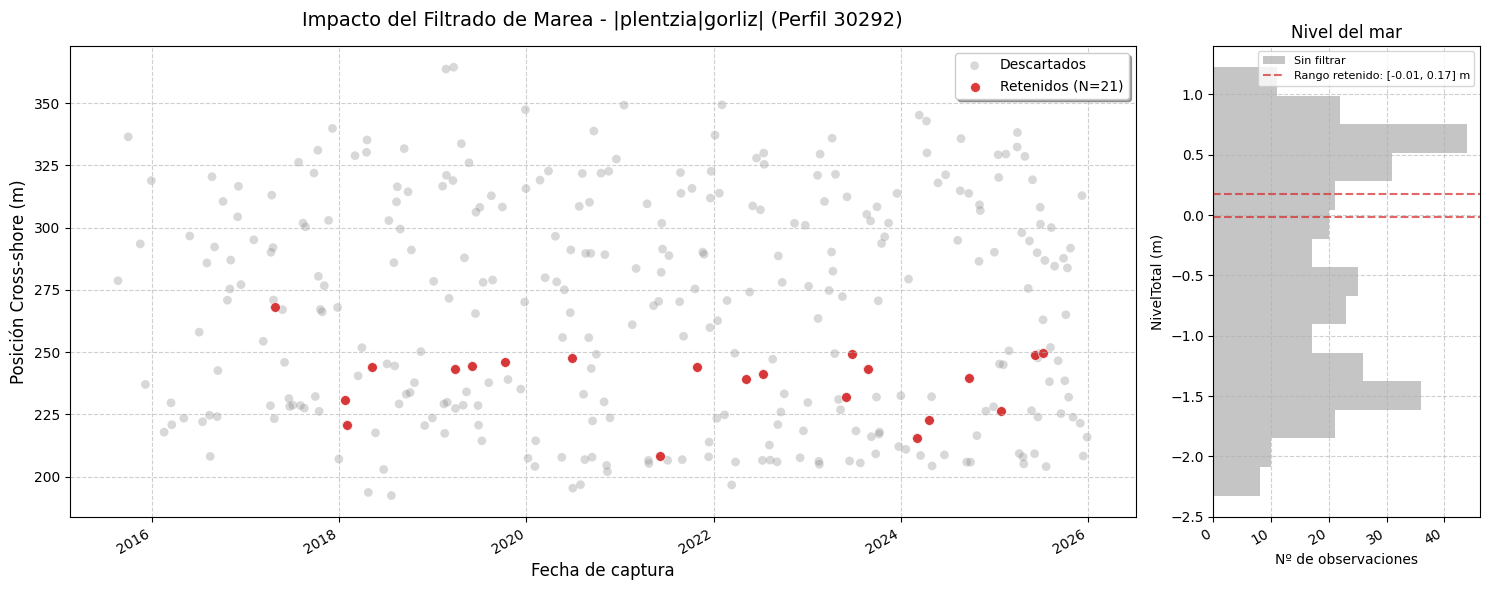

In [25]:
# Ejemplo de uso:
visualizar_resultado_filtro(
    df_original=profiles_shoreline_intersections, 
    df_filtrado=filtered_data,
    profile_id=30292,
    filtro_instancia=tidal_filter
)

--- Resumen de Filtrado SmartTidal ---
Perfil ID: 30140
Datos originales: 178 líneas
Datos retenidos:  18 líneas (10.1%)
--------------------------------------


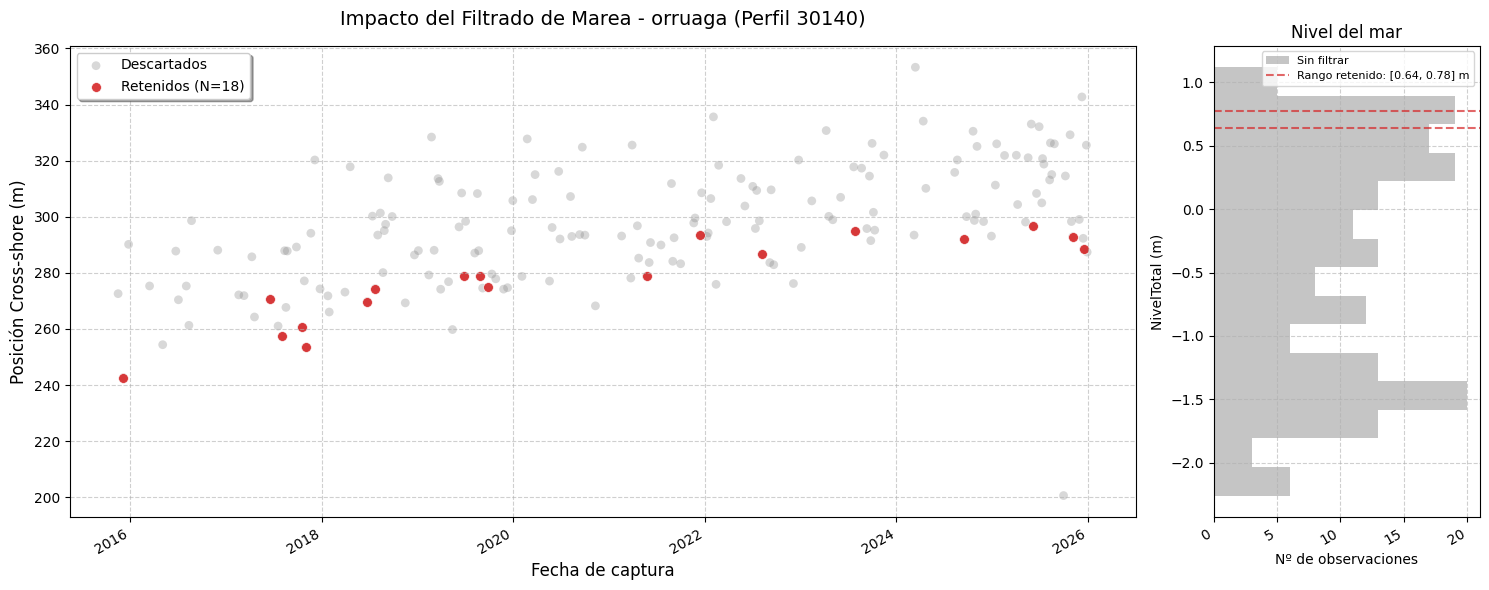

In [26]:
# Ejemplo de uso:
visualizar_resultado_filtro(
    df_original=profiles_shoreline_intersections, 
    df_filtrado=filtered_data,
    profile_id=30140,
    filtro_instancia=tidal_filter
)

In [9]:
from utils import ShorelineEvolutionAnalyzer

# Initialize the analyzer with a N-day temporal window
analyzer = ShorelineEvolutionAnalyzer(
    window='360D',               # Time-based window
    min_periods=2,               # Needs at least 2 points in those N days to compute a median
    profile_col="profile_id",
    date_col="datetime",         # Must match the datetime column outputted by the tidal filter
    pos_col="shoreline_position_m"
)

# 1. Ejecutar el pipeline completo sobre tus datos previamente filtrados por marea
smoothed_data = analyzer.fit_transform(filtered_data)

# 2. Extraer la tabla final con las tasas de evolución (m/año) y estadísticos
tasas_resultados = analyzer.rates_

# Ver los primeros resultados
display(tasas_resultados.head())

,profile_id,n_observations,rate_ols_m_yr,r_squared,p_value,rate_theilsen_m_yr,theilsen_ci_lower,theilsen_ci_upper,is_significant
0,29897,14,-0.315,0.088,0.3033,-0.387,-1.138,0.152,False
1,29901,14,0.628,0.107,0.2531,0.583,-0.988,2.158,False
2,29902,14,0.210,0.017,0.6552,0.206,-0.854,1.246,False
3,29903,14,0.508,0.093,0.2887,0.087,-1.069,1.296,False
4,29904,14,0.725,0.136,0.1941,0.813,-1.017,1.385,False


In [10]:
# tasas_resultados[tasas_resultados["n_observations"] > 10].sort_values(by="rate_theilsen_m_yr", ascending=True).head(50)

In [11]:
from scipy.stats import theilslopes, linregress

def visualizar_tendencia_perfil(df_suavizado, df_tasas, profile_id, 
                                date_col="datetime", pos_col="shoreline_position_m"):
    """
    Genera un gráfico analítico de la evolución de la línea de costa para un perfil,
    mostrando los datos estabilizados, la recta de regresión robusta (Theil-Sen), 
    la recta clásica (OLS) y un panel de métricas.
    """
    smoothed_col = f"{pos_col}_smoothed"
    
    # 1. Extraer los datos del perfil específico
    df_perfil = df_suavizado[
        (df_suavizado["profile_id"] == profile_id)
    ].copy()
        
    df_metricas = df_tasas[df_tasas["profile_id"] == profile_id]
    if df_metricas.empty:
        print(f"No se encontraron métricas calculadas para el perfil '{profile_id}'.")
        return

    # Retrieve the name of the beach and display it in the title
    playa = df_perfil["Playa"].iloc[0] if "Playa" in df_perfil.columns else "Desconocida"
    print(f"Visualizando tendencia para la playa '{playa}' y perfil '{profile_id}'.")
        
    metricas = df_metricas.iloc[0]
    
    # 2. Recalcular las rectas (Theil-Sen y OLS) para el ploteo
    df_perfil = df_perfil.dropna(subset=[smoothed_col])
    dias_desde_origen = (df_perfil[date_col] - pd.Timestamp("1970-01-01")).dt.days
    x_years = dias_desde_origen / 365.2425
    y_pos = df_perfil[smoothed_col]
    
    # Extraemos la pendiente y el intercepto Theil-Sen
    ts_res = theilslopes(y_pos, x_years, alpha=0.95)
    slope_ts = ts_res[0]
    intercept_ts = ts_res[1]
    y_fit_ts = slope_ts * x_years + intercept_ts
    
    # Extraemos la pendiente y el intercepto OLS
    ols_res = linregress(x_years, y_pos)
    slope_ols = ols_res.slope
    intercept_ols = ols_res.intercept
    y_fit_ols = slope_ols * x_years + intercept_ols
    
    # 3. Configurar el gráfico
    fig, ax = plt.subplots(figsize=(14, 6))

    # Visualizar los datos originales en gris
    ax.scatter(
        df_perfil[date_col], df_perfil[pos_col],
        color='gray', s=30, alpha=0.4, edgecolors='none',
        label='Posición original (sin suavizar)'
    )
    
    # Nube de puntos de las observaciones estabilizadas
    ax.scatter(
        df_perfil[date_col], y_pos, 
        color='#1f77b4', s=45, alpha=0.8, edgecolors='white', linewidth=0.5,
        label='Posición suavizada (Mediana Móvil)'
    )
               
    # Color dinámico para la línea de Theil-Sen según la significancia estadística
    is_sig = metricas['is_significant']
    color_linea = '#2ca02c' if is_sig else '#d62728' # Verde significativo, rojo no significativo
    
    # Trazar la regresión de Theil-Sen (Robusta)
    ax.plot(
        df_perfil[date_col], y_fit_ts, 
        color=color_linea, linewidth=2.5, linestyle='--', 
        label='Tendencia Robusta (Theil-Sen)'
    )
    
    # Trazar la regresión OLS (Mínimos Cuadrados)
    ax.plot(
        df_perfil[date_col], y_fit_ols,
        color='#ff7f0e', linewidth=2.0, linestyle=':', 
        label='Tendencia OLS'
    )
            
    # 4. Crear el panel de información lateral
    texto_metricas = (
        f"Métricas del Perfil {profile_id}\n"
        f"{'-'*30}\n"
        f"Observaciones (N) : {metricas['n_observations']}\n"
        f"Tasa Theil-Sen    : {metricas['rate_theilsen_m_yr']:.2f} m/año\n"
        f"IC 95%            : [{metricas['theilsen_ci_lower']:.2f}, {metricas['theilsen_ci_upper']:.2f}]\n"
        f"{'-'*30}\n"
        f"Tasa OLS          : {metricas['rate_ols_m_yr']:.2f} m/año\n"
        f"R² (Linealidad)   : {metricas['r_squared']:.2f}\n"
        f"p-valor           : {metricas['p_value']:.4f}\n"
        f"Significativo     : {'Sí ✅' if is_sig else 'No ❌'}"
    )
    
    # Propiedades estéticas de la caja de texto
    props = dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.95, edgecolor='#d3d3d3')
    
    # Anclar la caja a la derecha del gráfico
    ax.text(
        1.03, 0.5, texto_metricas, transform=ax.transAxes, 
        fontsize=10.5, verticalalignment='center', bbox=props, family='monospace'
    )
            
    # 5. Formateo y detalles finales
    ax.set_title(f"Evaluación de Tendencia a Largo Plazo - {playa} (Perfil {profile_id})", fontsize=14, pad=15)
    ax.set_xlabel("Fecha de captura", fontsize=12)
    ax.set_ylabel("Posición Cross-shore (m)", fontsize=12)
    
    # Posicionar la leyenda (ajustamos según la pendiente principal para no tapar datos)
    loc_leyenda = 'lower left' if slope_ts < 0 else 'upper right'
    ax.legend(loc='best', frameon=True, shadow=True)
    
    ax.grid(True, linestyle='--', alpha=0.5)
    fig.autofmt_xdate() # Rota las fechas en el eje X
    
    plt.tight_layout()
    plt.show()

Visualizando tendencia para la playa 'arrietara- atxabiribil' y perfil '30343'.


/var/folders/0l/bcxqcxms3bj1mvb90tys_lrw0000gn/T/ipykernel_11855/1878025204.py:116: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/opt/anaconda3/envs/geo/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


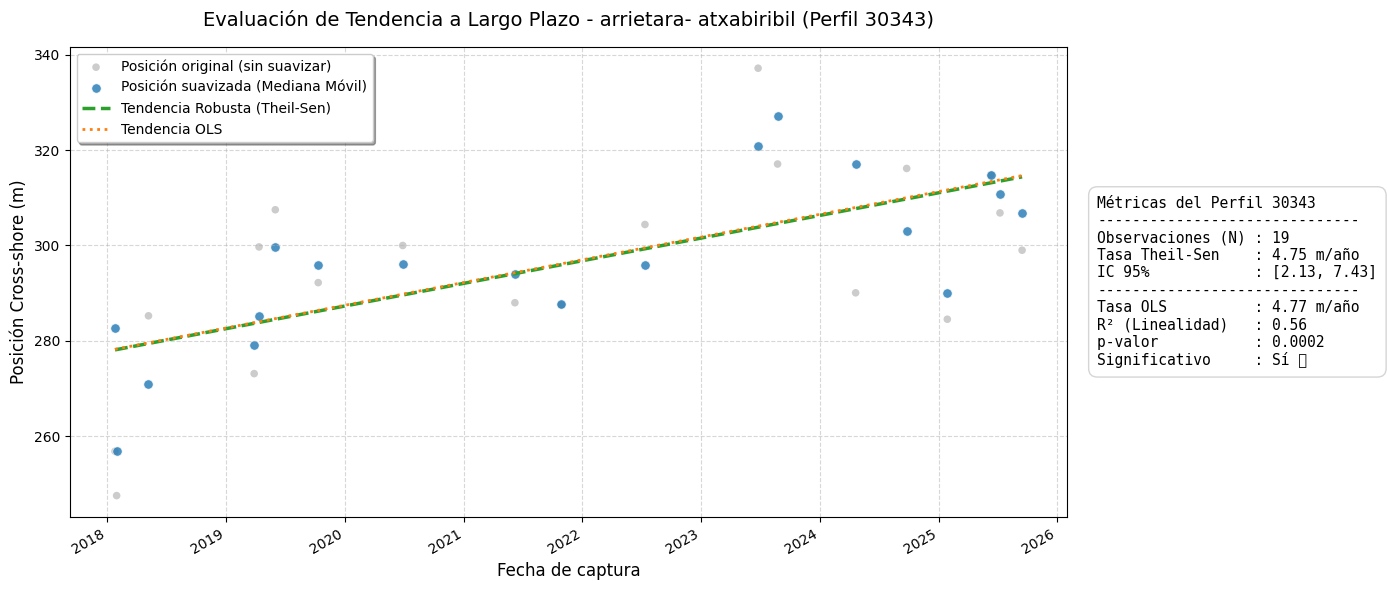

In [12]:
visualizar_tendencia_perfil(
    df_suavizado=smoothed_data, 
    df_tasas=tasas_resultados,
    profile_id=30343
)

Visualizando tendencia para la playa 'oriñón' y perfil '30459'.


/var/folders/0l/bcxqcxms3bj1mvb90tys_lrw0000gn/T/ipykernel_11855/1878025204.py:116: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/opt/anaconda3/envs/geo/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


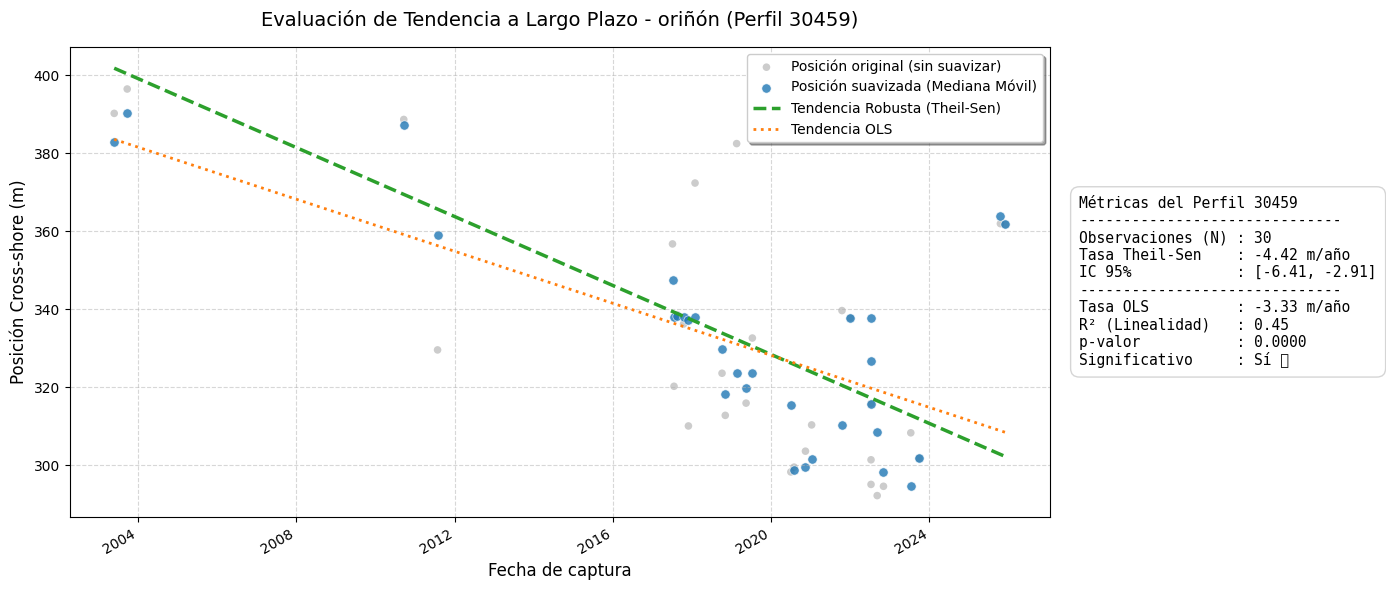

In [13]:
visualizar_tendencia_perfil(
    df_suavizado=smoothed_data, 
    df_tasas=tasas_resultados,
    profile_id=30459
)

Visualizando tendencia para la playa 'orruaga' y perfil '30140'.


/var/folders/0l/bcxqcxms3bj1mvb90tys_lrw0000gn/T/ipykernel_11855/1878025204.py:116: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/opt/anaconda3/envs/geo/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


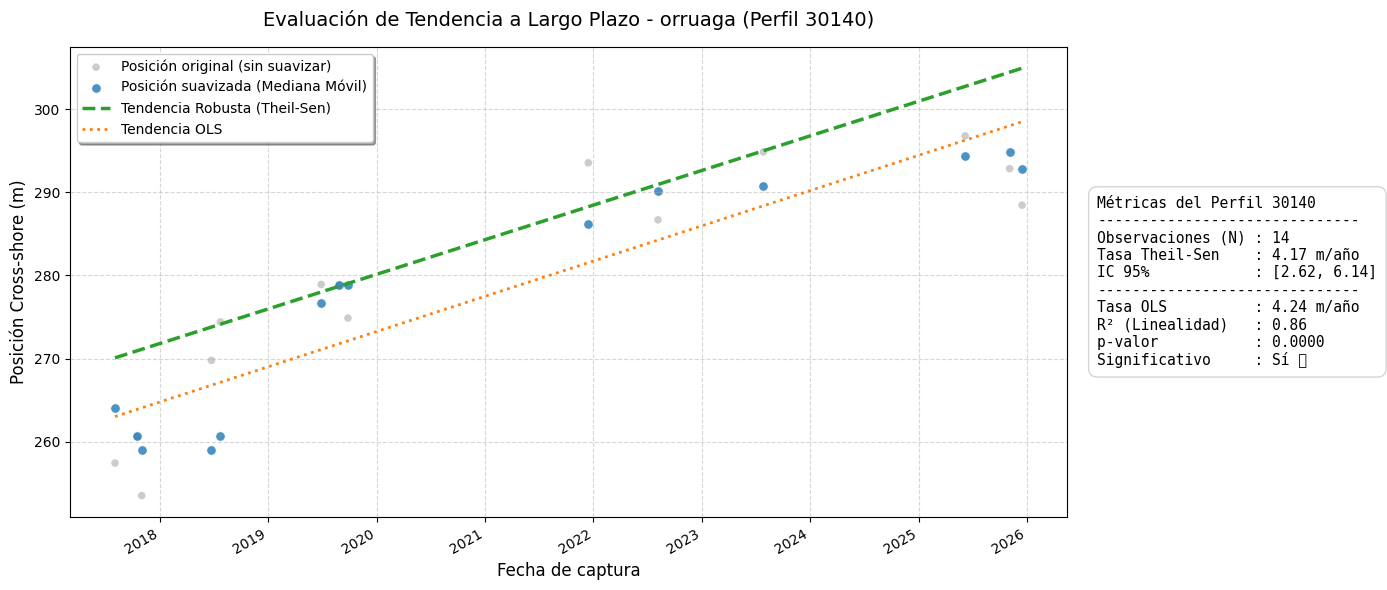

In [14]:
visualizar_tendencia_perfil(
    df_suavizado=smoothed_data, 
    df_tasas=tasas_resultados,
    profile_id=30140
)

Visualizando tendencia para la playa 'bañugues' y perfil '31639'.


/var/folders/0l/bcxqcxms3bj1mvb90tys_lrw0000gn/T/ipykernel_11855/1878025204.py:116: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/opt/anaconda3/envs/geo/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


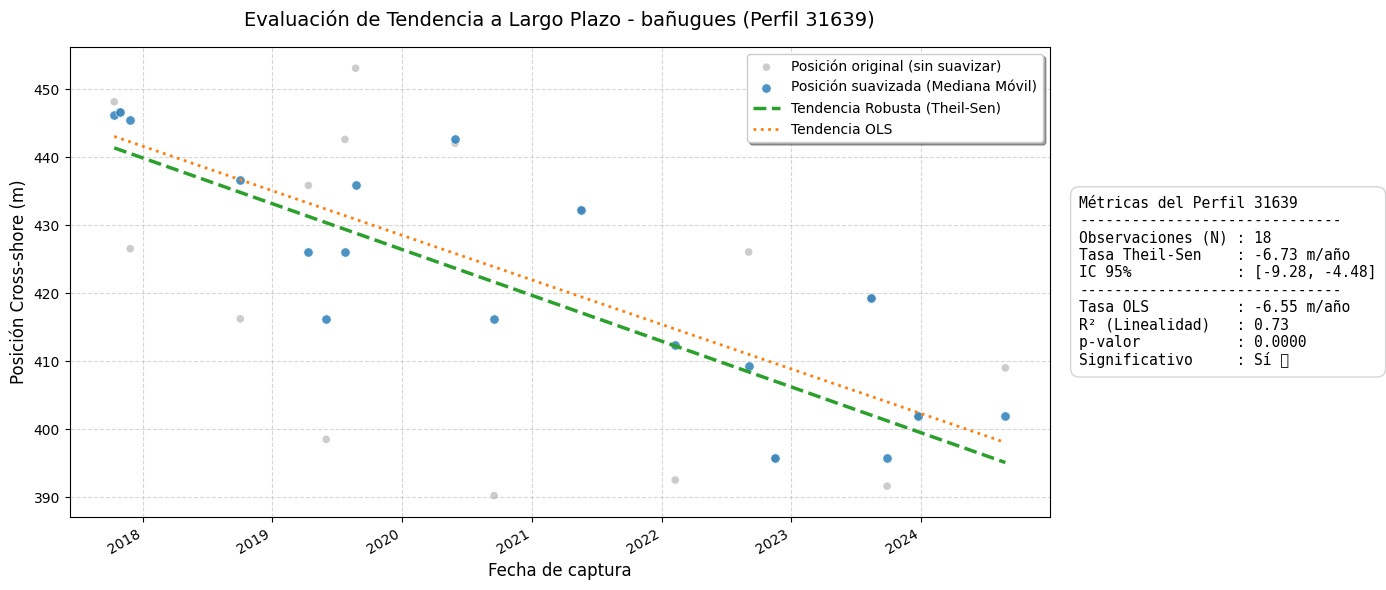

In [15]:
visualizar_tendencia_perfil(
    df_suavizado=smoothed_data, 
    df_tasas=tasas_resultados,
    profile_id=31639
)